# EDA: GNN-BERT Music Context Understanding
Exploratory analysis of the corpus, tag distribution, segment-graph statistics, and valence/arousal spread.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
import numpy as np
import matplotlib.pyplot as plt
from dataset import generate_synthetic_corpus, SAMPLE_TAGS
from graph_builder import build_segment_graph

corpus = generate_synthetic_corpus(n_tracks=200, seed=42)
print(f'Corpus size: {len(corpus)} tracks')
corpus[0]

f:\CSE425project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
f:\CSE425project\venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Corpus size: 200 tracks


{'track_id': 'synth_0000',
 'segment_features': [array([ 0.49671414, -0.1382643 ,  0.64768857,  1.5230298 , -0.23415338,
         -0.23413695,  1.5792128 ,  0.7674347 , -0.46947438,  0.54256004,
         -0.46341768, -0.46572974,  0.24196227, -1.9132802 , -1.7249179 ,
         -0.5622875 , -1.0128311 ,  0.31424734, -0.9080241 , -1.4123037 ],
        dtype=float32),
  array([ 1.4656488 , -0.2257763 ,  0.0675282 , -1.4247482 , -0.54438275,
          0.11092259, -1.1509936 ,  0.37569803, -0.6006387 , -0.29169375,
         -0.6017066 ,  1.8522782 , -0.01349723, -1.0577109 ,  0.82254493,
         -1.2208437 ,  0.2088636 , -1.9596701 , -1.328186  ,  0.19686124],
        dtype=float32),
  array([ 0.73846656,  0.17136829, -0.11564828, -0.30110368, -1.478522  ,
         -0.7198442 , -0.46063876,  1.0571222 ,  0.3436183 , -1.7630402 ,
          0.32408398, -0.38508227, -0.676922  ,  0.6116763 ,  1.0309995 ,
          0.93128014, -0.83921754, -0.3092124 ,  0.33126342,  0.9755451 ],
        dtype=

## Tag frequency distribution

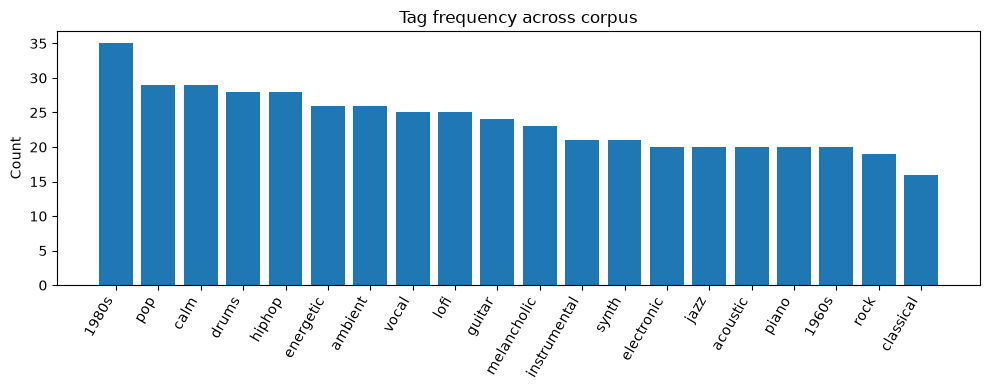

In [2]:
tag_matrix = np.stack([item['tags'] for item in corpus])
tag_counts = tag_matrix.sum(axis=0)

plt.figure(figsize=(10, 4))
order = np.argsort(-tag_counts)
plt.bar([SAMPLE_TAGS[i] for i in order], tag_counts[order])
plt.xticks(rotation=60, ha='right')
plt.ylabel('Count')
plt.title('Tag frequency across corpus')
plt.tight_layout()
plt.show()

## Valence / Arousal distribution 

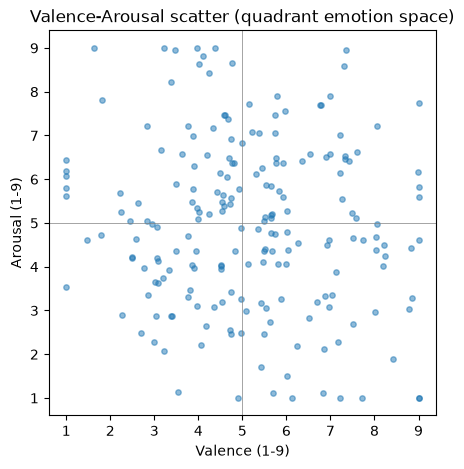

In [3]:
valence = [item['valence'] for item in corpus]
arousal = [item['arousal'] for item in corpus]

plt.figure(figsize=(5, 5))
plt.scatter(valence, arousal, alpha=0.5, s=15)
plt.xlabel('Valence (1-9)')
plt.ylabel('Arousal (1-9)')
plt.title('Valence-Arousal scatter (quadrant emotion space)')
plt.axvline(5, color='gray', lw=0.5)
plt.axhline(5, color='gray', lw=0.5)
plt.show()

## Segment-graph statistics

Mean nodes/graph: 12.00
Mean edges/graph: 22.00


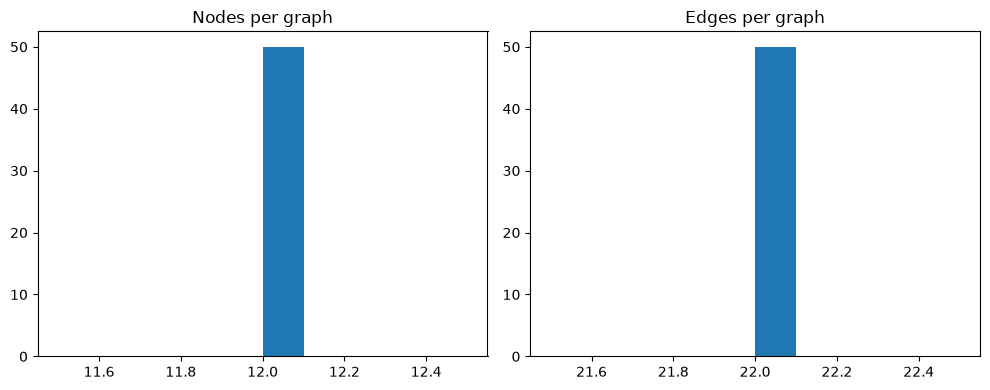

In [4]:
n_nodes, n_edges = [], []
for item in corpus[:50]:
    g = build_segment_graph(item['segment_features'], similarity_threshold=0.8)
    n_nodes.append(g.x.shape[0])
    n_edges.append(g.edge_index.shape[1])

print(f'Mean nodes/graph: {np.mean(n_nodes):.2f}')
print(f'Mean edges/graph: {np.mean(n_edges):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(n_nodes, bins=10); axes[0].set_title('Nodes per graph')
axes[1].hist(n_edges, bins=10); axes[1].set_title('Edges per graph')
plt.tight_layout()
plt.show()